# Worksheet — Perceptron, Logistic Regression and MLP

## 1. Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

import mlflow

## 2. Load and inspect the dataset

In [5]:
df = pd.read_csv("../DATASET/dataset_expandido.csv")

display(df.head())
print("Shape:", df.shape)
print("\nColunas disponiveis:", df.columns.tolist())

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Age_Code,Geração,JobSat_Class
0,1,I am a developer by profession,<18,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,Sem dado,...,5.0,0.0,0.0,Sem dado,Sem dado,65000.0,7.0,1,Gen Alpha,Medio
1,2,I am a developer by profession,35-44,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,Sem dado,Sem dado,65000.0,7.0,4,Millennials/Gen X,Medio
2,3,I am a developer by profession,45-54,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,5.0,0.0,0.0,Appropriate in length,Easy,65000.0,7.0,5,Gen X,Medio
3,4,I am learning to code,18-24,"Student, full-time",Sem dado,Apples,Sem dado,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,5.0,0.0,0.0,Too long,Easy,65000.0,7.0,2,Gen Z,Medio
4,5,I am a developer by profession,18-24,"Student, full-time",Sem dado,Apples,Sem dado,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,5.0,0.0,0.0,Too short,Easy,65000.0,7.0,2,Gen Z,Medio


Shape: (165437, 117)

Colunas disponiveis: ['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWor

# Part I — Classification with JobSat_Class

In [6]:
# Converter YearsCode e YearsCodePro para numerico
df['YearsCode_num'] = pd.to_numeric(df['YearsCode'], errors='coerce')
df['YearsCodePro_num'] = pd.to_numeric(
    df['YearsCodePro'].replace('Sem dado', np.nan), errors='coerce'
)

# Mapeamentos ordinais para colunas categoricas com ordem natural
edlevel_order = [[
    "Primary/elementary school",
    "Some college/university study without earning a degree",
    "Associate degree (A.A., A.S., etc.)",
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)",
    "Something else"
]]

orgsize_order = [[
    "Just me - I am a freelancer, sole proprietor, etc.",
    "2 to 9 employees",
    "10 to 19 employees",
    "20 to 99 employees",
    "100 to 499 employees",
    "500 to 999 employees",
    "1,000 to 4,999 employees",
    "5,000 to 9,999 employees",
    "10,000 or more employees"
]]

remotework_order = [["In-person", "Hybrid (some remote, some in-person)", "Remote"]]

icorpm_order = [["IC", "PM", "Both"]]

# Definir features e target para classificacao
clf_target_column = "JobSat_Class"

clf_feature_columns = [
    'YearsCode_num', 'YearsCodePro_num', 'WorkExp', 'Age_Code',
    'EdLevel', 'OrgSize', 'RemoteWork', 'ICorPM'
]

clf_df = df[clf_feature_columns + [clf_target_column]].copy().dropna()

# Encoders ordinais para as colunas categoricas
enc_edlevel = OrdinalEncoder(categories=edlevel_order,
                              handle_unknown='use_encoded_value', unknown_value=-1)
enc_orgsize = OrdinalEncoder(categories=orgsize_order,
                              handle_unknown='use_encoded_value', unknown_value=-1)
enc_remote  = OrdinalEncoder(categories=remotework_order,
                              handle_unknown='use_encoded_value', unknown_value=-1)
enc_icorpm  = OrdinalEncoder(categories=icorpm_order,
                              handle_unknown='use_encoded_value', unknown_value=-1)

clf_df['EdLevel_enc']    = enc_edlevel.fit_transform(clf_df[['EdLevel']])
clf_df['OrgSize_enc']    = enc_orgsize.fit_transform(clf_df[['OrgSize']])
clf_df['RemoteWork_enc'] = enc_remote.fit_transform(clf_df[['RemoteWork']])
clf_df['ICorPM_enc']     = enc_icorpm.fit_transform(clf_df[['ICorPM']])

# Features finais (todas numericas)
clf_features_final = [
    'YearsCode_num', 'YearsCodePro_num', 'WorkExp', 'Age_Code',
    'EdLevel_enc', 'OrgSize_enc', 'RemoteWork_enc', 'ICorPM_enc'
]

label_encoder = LabelEncoder()
y_clf = label_encoder.fit_transform(clf_df[clf_target_column])
X_clf = clf_df[clf_features_final]

print("Classes:", label_encoder.classes_)
print("Features shape:", X_clf.shape)
print("\nDistribuicao do target:")
print(pd.Series(y_clf).map(dict(enumerate(label_encoder.classes_))).value_counts())

Classes: ['Alto' 'Baixo' 'Medio']
Features shape: (122619, 8)

Distribuicao do target:
Medio    77458
Alto     32062
Baixo    13099
Name: count, dtype: int64


## 4. Split and scale the data

In [7]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled  = scaler_clf.transform(X_test_clf)

## 5. Experiment 1 — Perceptron baseline

In [8]:
mlflow.set_experiment("JobSat Classification - Perceptron vs Logistic Regression (fixed)")

with mlflow.start_run(run_name="Perceptron baseline"):
    perceptron = Perceptron(random_state=42)
    perceptron.fit(X_train_clf_scaled, y_train_clf)

    y_train_pred_perc = perceptron.predict(X_train_clf_scaled)
    y_test_pred_perc  = perceptron.predict(X_test_clf_scaled)

    train_acc_perceptron = accuracy_score(y_train_clf, y_train_pred_perc)
    test_acc_perceptron  = accuracy_score(y_test_clf,  y_test_pred_perc)

    mlflow.log_param("model", "Perceptron")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("train_accuracy", train_acc_perceptron)
    mlflow.log_metric("test_accuracy",  test_acc_perceptron)

print("Perceptron baseline")
print("Train accuracy:", train_acc_perceptron)
print("Test accuracy: ", test_acc_perceptron)
print("\nConfusion matrix:")
print(confusion_matrix(y_test_clf, y_test_pred_perc))
print("\nClassification report:")
print(classification_report(y_test_clf, y_test_pred_perc,
                             target_names=label_encoder.classes_))

c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
Traceback (most recent call last):
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\marco\AppData\Local\Programs\Python\P

Perceptron baseline
Train accuracy: 0.6192874254549161
Test accuracy:  0.6213505137824172

Confusion matrix:
[[  855     0  5557]
 [  309     0  2311]
 [ 1089    20 14383]]

Classification report:
              precision    recall  f1-score   support

        Alto       0.38      0.13      0.20      6412
       Baixo       0.00      0.00      0.00      2620
       Medio       0.65      0.93      0.76     15492

    accuracy                           0.62     24524
   macro avg       0.34      0.35      0.32     24524
weighted avg       0.51      0.62      0.53     24524



## 6. Experiment 2 — Logistic Regression baseline

In [9]:
with mlflow.start_run(run_name="Logistic Regression baseline"):
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train_clf_scaled, y_train_clf)

    y_train_pred_lr = log_reg.predict(X_train_clf_scaled)
    y_test_pred_lr  = log_reg.predict(X_test_clf_scaled)

    train_acc_lr = accuracy_score(y_train_clf, y_train_pred_lr)
    test_acc_lr  = accuracy_score(y_test_clf,  y_test_pred_lr)

    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("train_accuracy", train_acc_lr)
    mlflow.log_metric("test_accuracy",  test_acc_lr)

print("Logistic Regression baseline")
print("Train accuracy:", train_acc_lr)
print("Test accuracy: ", test_acc_lr)
print("\nConfusion matrix:")
print(confusion_matrix(y_test_clf, y_test_pred_lr))
print("\nClassification report:")
print(classification_report(y_test_clf, y_test_pred_lr,
                             target_names=label_encoder.classes_))

Logistic Regression baseline
Train accuracy: 0.6449156429991335
Test accuracy:  0.6452862502038819

Confusion matrix:
[[  846     0  5566]
 [  256     0  2364]
 [  513     0 14979]]

Classification report:
              precision    recall  f1-score   support

        Alto       0.52      0.13      0.21      6412
       Baixo       0.00      0.00      0.00      2620
       Medio       0.65      0.97      0.78     15492

    accuracy                           0.65     24524
   macro avg       0.39      0.37      0.33     24524
weighted avg       0.55      0.65      0.55     24524



c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 7. Experiment 3 — Perceptron learning rate

In [10]:
eta_values = [0.0001, 0.001, 0.01, 0.1, 1.0]
results_perceptron_eta = []

for eta in eta_values:
    with mlflow.start_run(run_name=f"Perceptron eta0={eta}"):
        model = Perceptron(eta0=eta, max_iter=1000, random_state=42)
        model.fit(X_train_clf_scaled, y_train_clf)

        train_acc = accuracy_score(y_train_clf, model.predict(X_train_clf_scaled))
        test_acc  = accuracy_score(y_test_clf,  model.predict(X_test_clf_scaled))

        mlflow.log_param("model",    "Perceptron")
        mlflow.log_param("eta0",     eta)
        mlflow.log_metric("train_accuracy", train_acc)
        mlflow.log_metric("test_accuracy",  test_acc)

        results_perceptron_eta.append({
            "eta0": eta, "train_accuracy": train_acc, "test_accuracy": test_acc
        })

results_perceptron_eta = pd.DataFrame(results_perceptron_eta)
display(results_perceptron_eta)

,eta0,train_accuracy,test_accuracy
0,0.0001,0.543412,0.543305
1,0.0010,0.543412,0.543305
2,0.0100,0.543412,0.543305
3,0.1000,0.565666,0.565813
4,1.0000,0.619287,0.621351


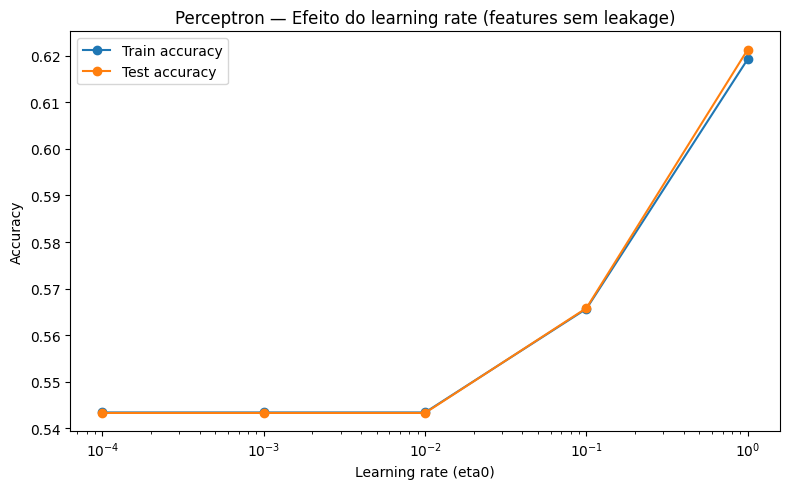

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(results_perceptron_eta["eta0"], results_perceptron_eta["train_accuracy"],
         marker="o", label="Train accuracy")
plt.plot(results_perceptron_eta["eta0"], results_perceptron_eta["test_accuracy"],
         marker="o", label="Test accuracy")
plt.xscale("log")
plt.xlabel("Learning rate (eta0)")
plt.ylabel("Accuracy")
plt.title("Perceptron — Efeito do learning rate (features sem leakage)")
plt.legend()
plt.tight_layout()
plt.show()

# Part II — Regression with ConvertedCompYearly

## 8. Feature engineering — features relevantes para salario



In [12]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

reg_target_column = "ConvertedCompYearly"

# Reutilizar as mesmas features engineered da classificacao
reg_feature_columns = [
    'YearsCode_num', 'YearsCodePro_num', 'WorkExp', 'Age_Code',
    'EdLevel_enc', 'OrgSize_enc', 'RemoteWork_enc', 'ICorPM_enc'
]

# Aplicar o mesmo encoding ao dataframe completo
df['YearsCode_num'] = pd.to_numeric(df['YearsCode'], errors='coerce')
df['YearsCodePro_num'] = pd.to_numeric(
    df['YearsCodePro'].replace('Sem dado', np.nan), errors='coerce'
)
df['EdLevel_enc']    = enc_edlevel.transform(df[['EdLevel']].fillna('Something else'))
df['OrgSize_enc']    = enc_orgsize.transform(df[['OrgSize']].fillna(df['OrgSize'].mode()[0]))
df['RemoteWork_enc'] = enc_remote.transform(df[['RemoteWork']].fillna(df['RemoteWork'].mode()[0]))
df['ICorPM_enc']     = enc_icorpm.transform(df[['ICorPM']].fillna(df['ICorPM'].mode()[0]))

reg_df = df[reg_feature_columns + [reg_target_column]].dropna()

X_reg = reg_df[reg_feature_columns]
y_reg = reg_df[reg_target_column]

display(reg_df.head())
print("Shape:", reg_df.shape)
print("\nCorrelacao com salario:")
print(reg_df[reg_feature_columns + [reg_target_column]].corr()[reg_target_column].sort_values(ascending=False))

,YearsCode_num,YearsCodePro_num,WorkExp,Age_Code,EdLevel_enc,OrgSize_enc,RemoteWork_enc,ICorPM_enc,ConvertedCompYearly
1,20.0,17.0,17.0,4,-1.0,-1.0,2.0,-1.0,65000.0
2,37.0,27.0,9.0,5,-1.0,-1.0,2.0,-1.0,65000.0
6,7.0,7.0,9.0,4,5.0,-1.0,2.0,-1.0,65000.0
9,15.0,11.0,9.0,4,-1.0,-1.0,2.0,-1.0,65000.0
11,30.0,25.0,9.0,5,5.0,-1.0,0.0,-1.0,65000.0


Shape: (122619, 9)

Correlacao com salario:
ConvertedCompYearly    1.000000
YearsCodePro_num       0.095790
YearsCode_num          0.095642
WorkExp                0.092765
Age_Code               0.080336
OrgSize_enc            0.071090
RemoteWork_enc         0.047878
EdLevel_enc            0.020408
ICorPM_enc                  NaN
Name: ConvertedCompYearly, dtype: float64


## 9. Split and scale

In [13]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled  = scaler_reg.transform(X_test_reg)

## 10. Helper functions

In [14]:
def calculate_rmse(y_true, y_pred):
    """Calcula o Root Mean Squared Error entre valores reais e previstos."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def run_mlp_experiment(
    run_name,
    hidden_layer_sizes,
    activation="relu",
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=500,
    random_state=42
):
    """
    Treina um MLPRegressor com os parametros fornecidos,
    regista as metricas no MLflow e devolve o modelo e os resultados.
    """
    with mlflow.start_run(run_name=run_name):
        model = MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=activation,
            learning_rate_init=learning_rate_init,
            alpha=alpha,
            max_iter=max_iter,
            random_state=random_state,
            early_stopping=False
        )
        model.fit(X_train_reg_scaled, y_train_reg)

        y_train_pred = model.predict(X_train_reg_scaled)
        y_test_pred  = model.predict(X_test_reg_scaled)

        train_rmse = calculate_rmse(y_train_reg, y_train_pred)
        test_rmse  = calculate_rmse(y_test_reg,  y_test_pred)
        train_r2   = r2_score(y_train_reg, y_train_pred)
        test_r2    = r2_score(y_test_reg,  y_test_pred)

        mlflow.log_param("model",              "MLPRegressor")
        mlflow.log_param("hidden_layer_sizes", hidden_layer_sizes)
        mlflow.log_param("activation",         activation)
        mlflow.log_param("learning_rate_init", learning_rate_init)
        mlflow.log_param("alpha",              alpha)
        mlflow.log_param("max_iter",           max_iter)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("test_rmse",  test_rmse)
        mlflow.log_metric("train_r2",   train_r2)
        mlflow.log_metric("test_r2",    test_r2)

        return model, {
            "run_name": run_name, "hidden_layer_sizes": hidden_layer_sizes,
            "activation": activation, "learning_rate_init": learning_rate_init,
            "train_rmse": train_rmse, "test_rmse": test_rmse,
            "train_r2": train_r2, "test_r2": test_r2
        }

## 11. Experiment 4 — Baseline MLP

In [15]:
mlflow.set_experiment("ConvertedCompYearly Regression - MLP (fixed)")

baseline_model, baseline_results = run_mlp_experiment(
    run_name="MLP baseline",
    hidden_layer_sizes=(50,),
    activation="relu",
    learning_rate_init=0.001,
    max_iter=500
)

baseline_results

Traceback (most recent call last):
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

{'run_name': 'MLP baseline',
 'hidden_layer_sizes': (50,),
 'activation': 'relu',
 'learning_rate_init': 0.001,
 'train_rmse': np.float64(111647.26554237833),
 'test_rmse': np.float64(113950.12478512115),
 'train_r2': 0.01793186948083303,
 'test_r2': 0.015176037386538055}

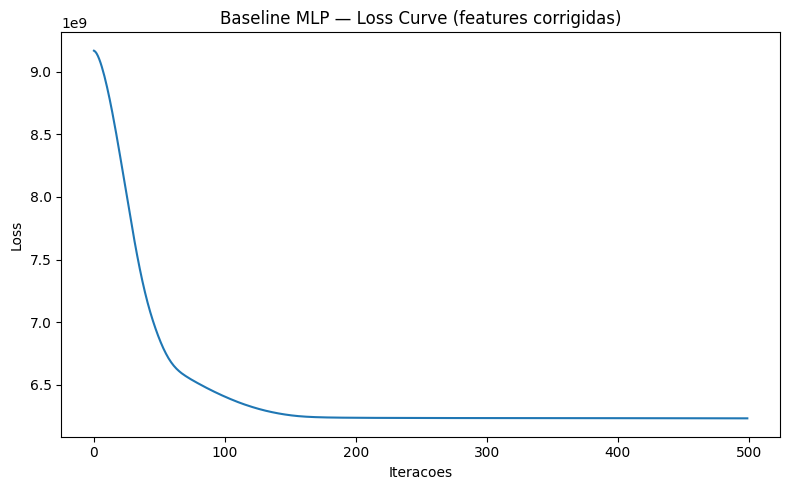

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_model.loss_curve_)
plt.xlabel("Iteracoes")
plt.ylabel("Loss")
plt.title("Baseline MLP — Loss Curve (features corrigidas)")
plt.tight_layout()
plt.show()

## 12. Experiment 5 — Underfitting vs Overfitting

In [17]:
experiments_size = [
    {"run_name": "Small MLP - possible underfitting",  "hidden_layer_sizes": (5,),       "learning_rate_init": 0.001, "max_iter": 500},
    {"run_name": "Medium MLP",                         "hidden_layer_sizes": (50,),      "learning_rate_init": 0.001, "max_iter": 500},
    {"run_name": "Large MLP - possible overfitting",   "hidden_layer_sizes": (200, 100), "learning_rate_init": 0.001, "max_iter": 500}
]

mlp_results  = []
trained_models = {}

for exp in experiments_size:
    model, results = run_mlp_experiment(**exp)
    mlp_results.append(results)
    trained_models[exp["run_name"]] = model

mlp_results_df = pd.DataFrame(mlp_results)
display(mlp_results_df)

c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,run_name,hidden_layer_sizes,activation,learning_rate_init,train_rmse,test_rmse,train_r2,test_r2
0,Small MLP - possible underfitting,"(5,)",relu,0.001,111942.536933,114174.035504,0.012730,0.011302
1,Medium MLP,"(50,)",relu,0.001,111647.265542,113950.124785,0.017932,0.015176
2,Large MLP - possible overfitting,"(200, 100)",relu,0.001,110758.651286,113356.313779,0.033502,0.025413


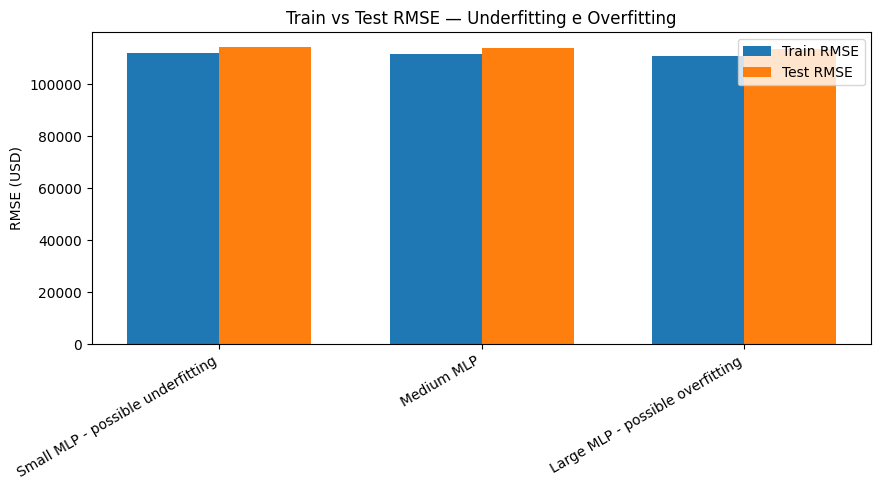

In [18]:
x = np.arange(len(mlp_results_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, mlp_results_df["train_rmse"], width, label="Train RMSE")
plt.bar(x + width / 2, mlp_results_df["test_rmse"],  width, label="Test RMSE")
plt.xticks(x, mlp_results_df["run_name"], rotation=30, ha="right")
plt.ylabel("RMSE (USD)")
plt.title("Train vs Test RMSE — Underfitting e Overfitting")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Experiment 6 — Loss curves

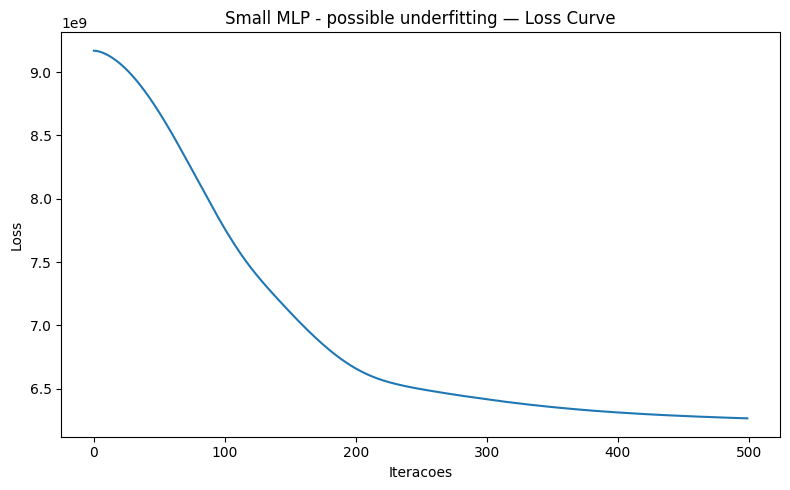

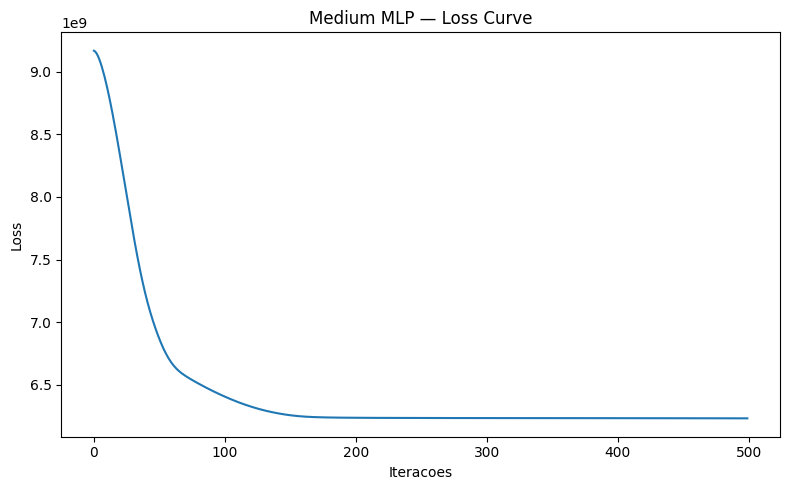

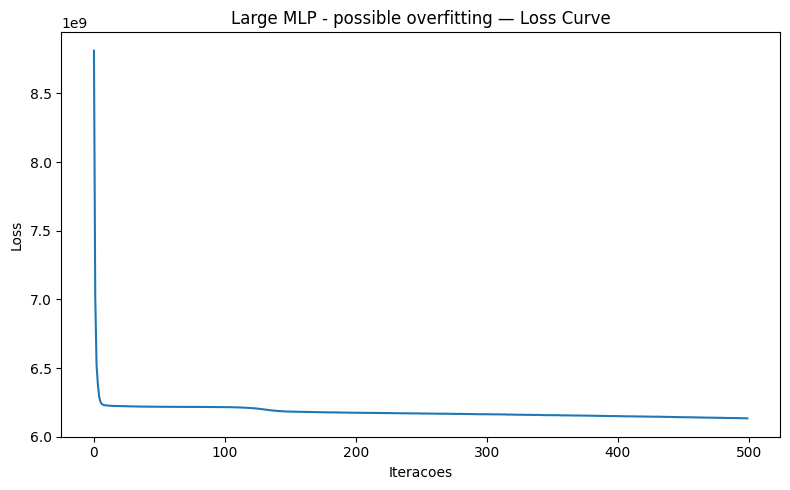

In [19]:
for name, model in trained_models.items():
    plt.figure(figsize=(8, 5))
    plt.plot(model.loss_curve_)
    plt.xlabel("Iteracoes")
    plt.ylabel("Loss")
    plt.title(name + " — Loss Curve")
    plt.tight_layout()
    plt.show()

## 14. Experiment 7 — Effect of learning rate

In [20]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_results = []
lr_models  = {}

for lr in learning_rates:
    model, results = run_mlp_experiment(
        run_name=f"MLP learning_rate={lr}",
        hidden_layer_sizes=(50,),
        activation="relu",
        learning_rate_init=lr,
        max_iter=500
    )
    lr_results.append(results)
    lr_models[f"lr={lr}"] = model

lr_results_df = pd.DataFrame(lr_results)
display(lr_results_df)

c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,run_name,hidden_layer_sizes,activation,learning_rate_init,train_rmse,test_rmse,train_r2,test_r2
0,MLP learning_rate=0.0001,"(50,)",relu,0.0001,118151.819711,120437.669214,-0.099832,-0.100155
1,MLP learning_rate=0.001,"(50,)",relu,0.0010,111647.265542,113950.124785,0.017932,0.015176
2,MLP learning_rate=0.01,"(50,)",relu,0.0100,111106.782501,113564.729546,0.027417,0.021826
3,MLP learning_rate=0.1,"(50,)",relu,0.1000,111481.318605,113834.160019,0.020849,0.017179


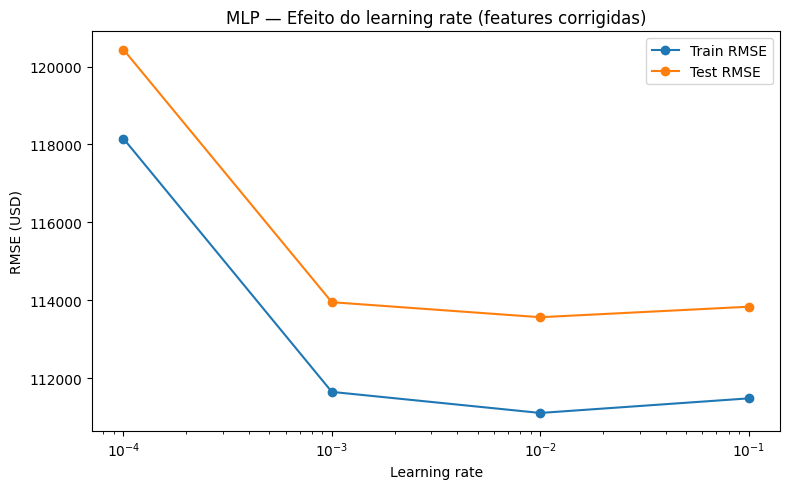

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(lr_results_df["learning_rate_init"], lr_results_df["train_rmse"],
         marker="o", label="Train RMSE")
plt.plot(lr_results_df["learning_rate_init"], lr_results_df["test_rmse"],
         marker="o", label="Test RMSE")
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("RMSE (USD)")
plt.title("MLP — Efeito do learning rate (features corrigidas)")
plt.legend()
plt.tight_layout()
plt.show()

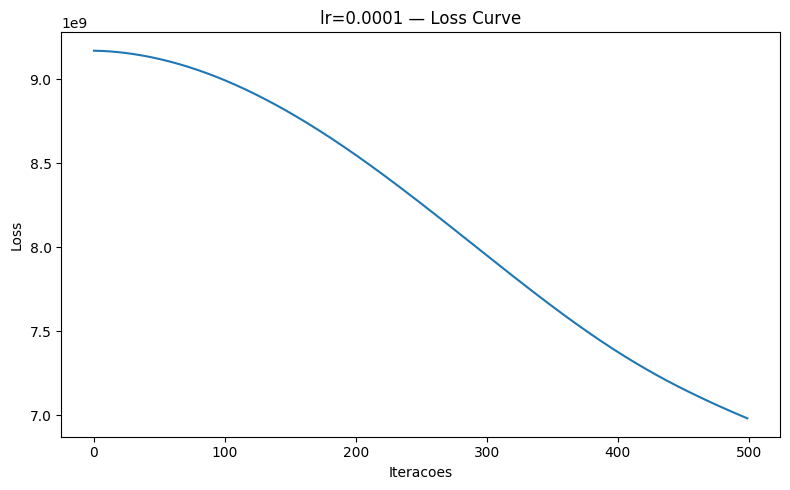

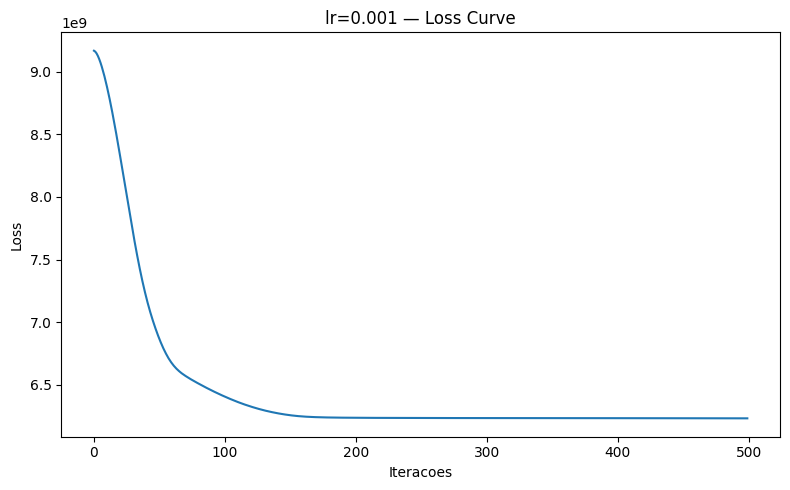

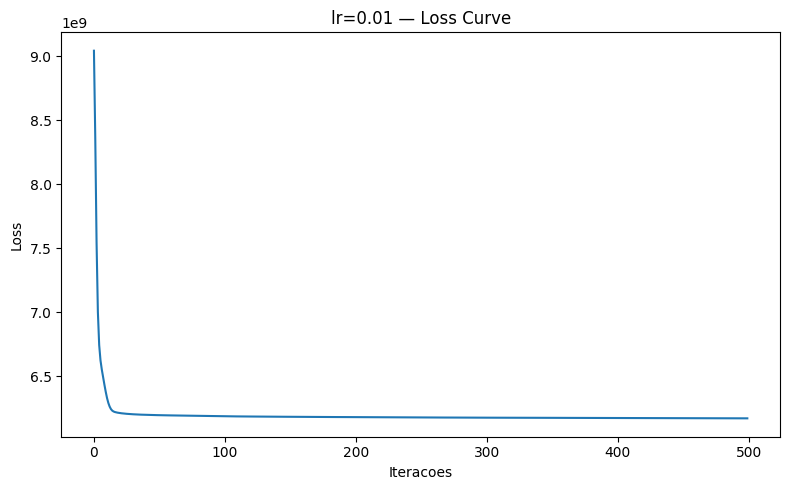

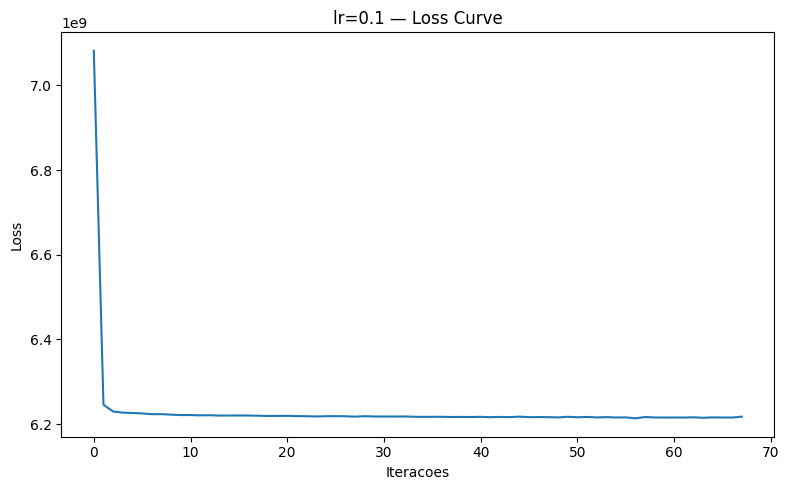

In [22]:
for name, model in lr_models.items():
    plt.figure(figsize=(8, 5))
    plt.plot(model.loss_curve_)
    plt.xlabel("Iteracoes")
    plt.ylabel("Loss")
    plt.title(name + " — Loss Curve")
    plt.tight_layout()
    plt.show()

# Resultados e Análise de Experiências

## Introdução

Os resultados mostram que modelos mais avançados, como a Regressão Logística e o MLP, apresentam melhor desempenho na classificação e previsão quando comparados com modelos neuronais mais simples, como o Perceptron.

---

# Parte 1 — Classificação

## Análise de Experiências

### Perceptron eta0 = 1.0
Uma taxa de aprendizagem elevada tornou o treino menos estável, afetando negativamente a precisão do modelo.

### Perceptron eta0 = 0.1
A redução da taxa de aprendizagem permitiu obter resultados mais consistentes e uma melhor convergência.

### Perceptron eta0 = 0.01
Este valor apresentou um equilíbrio adequado entre estabilidade e capacidade de aprendizagem do modelo.

### Perceptron eta0 = 0.001
Uma taxa de aprendizagem mais baixa tornou o treino mais lento, embora mantendo resultados estáveis.

### Perceptron eta0 = 0.0001
O modelo aprendeu de forma muito lenta, limitando a melhoria do desempenho ao longo das épocas.

### Logistic Regression Baseline
A Regressão Logística apresentou o melhor desempenho global, demonstrando maior capacidade de generalização.

### Perceptron Baseline
O modelo baseline serviu como referência inicial, evidenciando limitações em comparação com métodos mais robustos.

---

# Parte 2 — Regressão com MLP

## Análise de Experiências

### MLP com configuração inicial
O modelo conseguiu capturar relações não lineares nos dados, obtendo resultados superiores aos métodos lineares tradicionais.

### MLP com alteração do número de neurónios
O aumento da complexidade da rede melhorou a capacidade de aprendizagem, mas também aumentou o risco de overfitting.

### MLP com diferentes taxas de aprendizagem
Taxas de aprendizagem moderadas proporcionaram uma convergência mais estável e melhores previsões.

### MLP com diferentes números de épocas
O aumento do número de épocas permitiu reduzir o erro até um determinado ponto, após o qual os ganhos se tornaram reduzidos.

### MLP com regularização/ajustes adicionais
A aplicação de técnicas de ajuste ajudou a melhorar a generalização e a estabilidade do modelo.

---

# Conclusão

Em conclusão, os resultados obtidos demonstram que a escolha da arquitetura e dos hiperparâmetros influencia significativamente o desempenho dos modelos, verificando-se que métodos mais avançados, como a Regressão Logística e o MLP, apresentam maior capacidade de generalização e melhor desempenho na resolução de problemas de classificação e regressão quando comparados com modelos mais simples, como o Perceptron.